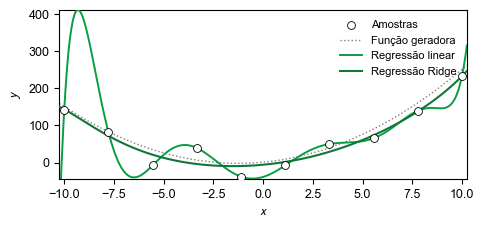

In [3]:

import matplotlib.pyplot as plt
import numpy as np


cm = 1 / 2.54
plt.rcParams.update({
    "font.family": "Arial",
    "mathtext.fontset": "stixsans",
    "font.size": 9,
})

COR_PRIM = "#117738"
COR_SEC = "#099E42"

# ============================================================
# Ridge com transformação polinomial em x
# ============================================================
np.random.seed(2)

# Funcao verdadeira (suave)
def f_true(x):
    return 2*x**2 + 5*x + 1
    #return np.sin(np.pi * x)

# Dados de treino, poucos e ruidosos
n_train = 10
x_train = np.linspace(-10, 10, n_train)
y_train = f_true(x_train) + 20.0 * np.random.randn(n_train)

# Grade densa para plotar as curvas ajustadas
x_grid = np.linspace(x_train.min()- 0.25, x_train.max()+ 0.25, 400)
y_grid_true = f_true(x_grid)

# Base polinomial de grau alto, capaz de sobreajustar facilmente
grau = 9
def poli_base(x, grau):
    return np.vstack([x ** k for k in range(1, grau + 1)]).T

X_train_raw = poli_base(x_train, grau)
X_grid_raw = poli_base(x_grid, grau)

# Padronizar colunas com base no treino, para que a penalidade L2
# trate todos os termos polinomiais em pe de igualdade
mu = X_train_raw.mean(axis=0)
sd = X_train_raw.std(axis=0)
X_train_std = (X_train_raw - mu) / sd
X_grid_std = (X_grid_raw - mu) / sd

# Centrar y no treino, para tratar o intercepto fora da regularizacao
y_mean = y_train.mean()
y_train_c = y_train - y_mean

# OLS sobre a base polinomial padronizada
beta_ols = np.linalg.lstsq(X_train_std, y_train_c, rcond=None)[0]
y_pred_ols = X_grid_std @ beta_ols + y_mean

# Ridge sobre a mesma base polinomial padronizada
alpha_ridge = 0.05
beta_ridge = np.linalg.solve(
    X_train_std.T @ X_train_std + alpha_ridge * np.eye(grau),
    X_train_std.T @ y_train_c,
)
y_pred_ridge = X_grid_std @ beta_ridge + y_mean

# Plot
fig1, ax1 = plt.subplots(figsize=(12 * cm, 5.5 * cm), layout="constrained")


ax1.scatter(x_train, y_train, c="white", edgecolors="black", linewidth=0.6,
            s=32, marker="o", zorder=5, label="Amostras")

ax1.plot(x_grid, y_grid_true, color="gray", linestyle=":", linewidth=1.0,
         label="Função geradora", zorder=2)

ax1.plot(x_grid, y_pred_ols, color=COR_SEC, linewidth=1.4,
         label=f"Regressão linear", zorder=3)
ax1.plot(x_grid, y_pred_ridge, color=COR_PRIM, linewidth=1.5,
         label=f"Regressão Ridge", zorder=4)



ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$y$")

x_min = x_train.min() - 0.25
x_max = x_train.max() + 0.25
ax1.set_xlim(x_min, x_max)

mask = (x_grid >= x_train.min()) & (x_grid <= x_train.max())
y_min = y_pred_ols[mask].min()
y_max = y_pred_ols[mask].max()
ax1.set_ylim(y_min - 0.25, y_max + 0.25)

ax1.legend(loc="upper right", fontsize=8, frameon=False)

plt.savefig("figuras/exemplo_ridge.png", dpi=300)
